In [1]:
import pandas as pd

df = pd.read_csv("heart-disease.csv")
print (df)
X = df.drop(columns=["target"])
y = df["target"]


     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [2]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top Features (Mutual Information):")
print(mi_df)


Top Features (Mutual Information):
thal        0.124872
ca          0.124288
cp          0.113881
exang       0.097686
oldpeak     0.094599
slope       0.091909
chol        0.065786
thalach     0.061475
fbs         0.055753
restecg     0.035308
sex         0.023080
trestbps    0.000000
age         0.000000
dtype: float64


In [3]:
from sklearn.feature_selection import chi2, SelectKBest

X_chi = X.copy()
X_chi = X_chi - X_chi.min()   # make all values non-negative

chi_selector = SelectKBest(chi2, k=8)   # choose top 8 features
chi_selector.fit(X_chi, y)

chi_features = X.columns[chi_selector.get_support()]
print("Top Features (Chi-Square):")
print(chi_features)


Top Features (Chi-Square):
Index(['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca'], dtype='str')


In [4]:
selected_features = chi_features   # or mi_df.index[:8]
X_selected = X[selected_features]

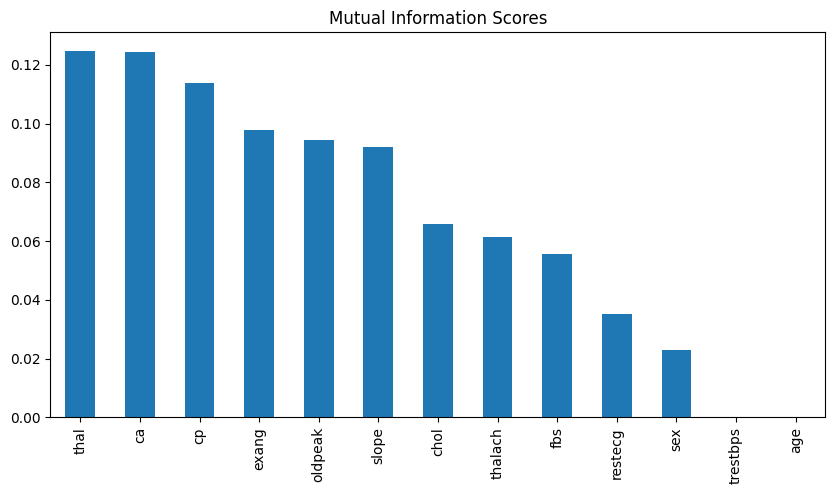

In [5]:
import os
import matplotlib.pyplot as plt

# Ensure plots folder exists
os.makedirs("plots", exist_ok=True)

# Plot and save
mi_df.plot(kind="bar", figsize=(10,5), title="Mutual Information Scores")
plt.savefig("plots/mutual_information.png")